### ================================
### **1️⃣ IMPORT LIBRARIES**
### ================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

c:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### ================================
## **2️⃣ LOAD DATA**
### ================================


In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


### ================================
## **3️⃣ DATA CLEANING**
### ================================

In [3]:
# Convert to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Keep only delivered orders
orders = orders[orders['order_status'] == 'delivered']

# Merge all datasets
df = orders.merge(order_items, on='order_id', how='left')
df = df.merge(order_payments, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(products, on='product_id', how='left')

print("Datasets merged successfully.")

Datasets merged successfully.


### ================================
## **4️⃣ MISSING VALUE CHECK**
### ================================

In [4]:
missing_values = df.isnull().sum()
print("\nMissing Values Summary:\n", missing_values[missing_values > 0])

# Drop rows where delivery date is missing
df = df.dropna(subset=['order_delivered_customer_date'])

# Fill missing product categories with "Unknown"
df['product_category_name'] = df['product_category_name'].fillna("Unknown")


Missing Values Summary:
 order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name            1628
product_name_lenght              1628
product_description_lenght       1628
product_photos_qty               1628
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
dtype: int64


### ================================
## **5️⃣ FEATURE ENGINEERING**
### ================================

In [6]:
df['total_price'] = df['price'] + df['freight_value']
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Delivery time in days
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Delivery Delay Classification
df['delivery_status'] = np.where(
    df['delivery_time_days'] > 10, "Delayed", "On-Time"
)

print("Feature Engineering Completed.")

Feature Engineering Completed.


### ================================
## **6️⃣ OUTLIER REMOVAL (IQR METHOD)**
### ================================

In [7]:
Q1 = df['total_price'].quantile(0.25)
Q3 = df['total_price'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['total_price'] >= Q1 - 1.5 * IQR) &
    (df['total_price'] <= Q3 + 1.5 * IQR)
]

print("Outliers Removed.")

Outliers Removed.


### ================================
## **7️⃣ KPI CALCULATIONS**
### ================================

In [8]:
total_revenue = df['total_price'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique()
average_order_value = total_revenue / total_orders

# Monthly Revenue
monthly_revenue = df.groupby('month')['total_price'].sum().reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

# Revenue Growth %
monthly_revenue['growth_%'] = monthly_revenue['total_price'].pct_change() * 100

print("\n===== BUSINESS KPIs =====")
print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value,2))



===== BUSINESS KPIs =====
Total Revenue: 10909550.51
Total Orders: 88914
Total Customers: 86056
Average Order Value: 122.7


### ================================
## **8️⃣ RFM CUSTOMER SEGMENTATION**
### ================================

In [9]:
snapshot_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_price': 'sum'
})

In [10]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster Interpretation Table
cluster_profile = rfm.groupby('Cluster').mean()
print("\nCluster Profile:\n", cluster_profile)


Cluster Profile:
             Recency  Frequency     Monetary
Cluster                                    
0        127.245485   1.092539   110.184819
1        237.721854  11.708609  1352.496490
2        387.489366   1.102927   109.392560
3        229.121641   3.021786   340.182916


### ================================
## **9️⃣ SALES FORECASTING WITH EVALUATION**
### ================================


In [11]:
daily_revenue = (
    df.groupby(df['order_purchase_timestamp'].dt.date)['total_price']
    .sum()
    .reset_index()
)

daily_revenue.columns = ['ds', 'y']

#### **Train-Test Split (Last 30 days for testing)**

In [12]:
train = daily_revenue[:-30]
test = daily_revenue[-30:]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

08:55:55 - cmdstanpy - INFO - Chain [1] start processing
08:55:56 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
print(forecast.dtypes)

ds                            datetime64[ns]
trend                                float64
yhat_lower                           float64
yhat_upper                           float64
trend_lower                          float64
trend_upper                          float64
additive_terms                       float64
additive_terms_lower                 float64
additive_terms_upper                 float64
weekly                               float64
weekly_lower                         float64
weekly_upper                         float64
multiplicative_terms                 float64
multiplicative_terms_lower           float64
multiplicative_terms_upper           float64
yhat                                 float64
dtype: object


In [14]:
print(test.dtypes)

ds     object
y     float64
dtype: object


#### Convert both columns explicitly to datetime before merging.Because there is an error of datatypes from (ds and y)

In [15]:
forecast['ds'] = pd.to_datetime(forecast['ds'])
test['ds'] = pd.to_datetime(test['ds'])

In [16]:
# Merge predictions with test data
forecast_test = forecast[['ds','yhat']].merge(test, on='ds')

In [17]:
# Evaluation Metrics
mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
print("\nForecast Evaluation:")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))


Forecast Evaluation:
MAE: 9522.24
RMSE: 11154.99


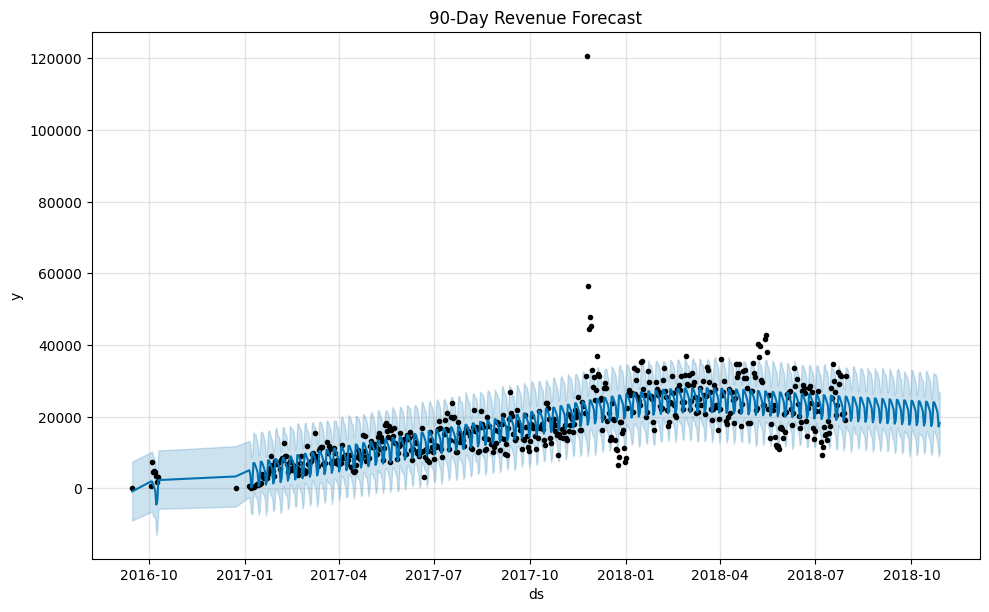

In [18]:
# Future 90-day forecast
future_90 = model.make_future_dataframe(periods=90)
forecast_90 = model.predict(future_90)

model.plot(forecast_90)
plt.title("90-Day Revenue Forecast")
plt.show()

### ================================
## **🔟 EXPORT FILES FOR POWER BI**
### ================================

In [19]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)
monthly_revenue.to_csv("monthly_revenue.csv", index=False)
rfm.to_csv("customer_segmentation.csv", index=False)
cluster_profile.to_csv("cluster_profile.csv")
forecast_90[['ds','yhat','yhat_lower','yhat_upper']].to_csv("sales_forecast.csv", index=False)

print("\nAll Advanced Files Exported Successfully!")
print("Project Ready for Power BI 🚀")


All Advanced Files Exported Successfully!
Project Ready for Power BI 🚀


In [21]:
# ==========================================
# Customer Segmentation 
# ==========================================

In [23]:
# 2️⃣ Load YOUR cleaned dataset
df = pd.read_csv("cleaned_ecommerce_data.csv")

# 3️⃣ Convert order_purchase_timestamp to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 4️⃣ Create Snapshot Date (last date + 1 day)
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 5️⃣ Create RFM Table
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'count',                                                   # Frequency
    'payment_value': 'sum'                                                 # Monetary
})

# 6️⃣ Rename Columns Properly
rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

# 7️⃣ Reset index so customer_unique_id becomes a column
rfm = rfm.reset_index()

print("RFM Table Preview:")
print(rfm.head())

# 8️⃣ Scale the Data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# 9️⃣ Apply KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 🔟 Save Correct Segmentation File
rfm.to_csv("customer_segmentation_corrected.csv", index=False)

print("Customer segmentation file created successfully!")

RFM Table Preview:
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
Customer segmentation file created successfully!
